In [1]:
import google.colab
google.colab.drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [3]:
df =pd.read_csv("/content/gdrive/MyDrive/Urbancomputing dataset2.csv")
df.head()

,event_id,gmv_PGA,gmv_SA(0.4),gmv_SA(0.6),gmv_SA(0.66),gmv_SA(0.89),gmv_SA(1.0),custom_site_id,lon,lat
0,2,0.115742,0.129177,0.177192,0.176267,0.300182,0.118107,d2bydwhg,-77.57891,5.39488
1,2,0.237877,0.329959,1.327690,0.071606,0.463469,0.154407,d2bydwsg,-77.57891,5.39757
2,2,0.187592,0.132305,0.329602,0.201738,0.138693,0.244993,d2bydxhf,-77.57891,5.40027
3,2,0.177796,0.155783,0.756833,0.227645,0.178625,0.100783,d2bydxsf,-77.57891,5.40297
4,2,0.529035,0.359734,0.131076,0.193713,0.124024,0.119915,d2byf8hf,-77.57891,5.40567


# Data Understanding


In [4]:
print("\n Data Info ")
print(df.info())
print("\n Descriptive Stats")
print(df.describe())


 Data Info 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 10 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   event_id        1048575 non-null  int64  
 1   gmv_PGA         1048575 non-null  float64
 2   gmv_SA(0.4)     1048575 non-null  float64
 3   gmv_SA(0.6)     1048575 non-null  float64
 4   gmv_SA(0.66)    1048575 non-null  float64
 5   gmv_SA(0.89)    1048575 non-null  float64
 6   gmv_SA(1.0)     1048575 non-null  float64
 7   custom_site_id  1048575 non-null  object 
 8   lon             1048575 non-null  float64
 9   lat             1048575 non-null  float64
dtypes: float64(8), int64(1), object(1)
memory usage: 80.0+ MB
None

 Descriptive Stats
        event_id       gmv_PGA   gmv_SA(0.4)   gmv_SA(0.6)  gmv_SA(0.66)  \
count  1048575.0  1.048575e+06  1.048575e+06  1.048575e+06  1.048575e+06   
mean         2.0  1.559921e+00  2.505952e+00  1.779634e+00  1.522504e+

In [5]:
gmv_cols = ['gmv_PGA', 'gmv_SA(0.4)', 'gmv_SA(0.6)', 'gmv_SA(0.66)', 'gmv_SA(0.89)', 'gmv_SA(1.0)']

print("\nUnique event_id:", df['event_id'].unique())
print("Spatial Range:")
print("Lon:", df['lon'].min(), "to", df['lon'].max())
print("Lat:", df['lat'].min(), "to", df['lat'].max())


Unique event_id: [2]
Spatial Range:
Lon: -77.57891 to -75.47354
Lat: 5.39488 to 9.04792


# Data Cleaning


In [6]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
event_id          0
gmv_PGA           0
gmv_SA(0.4)       0
gmv_SA(0.6)       0
gmv_SA(0.66)      0
gmv_SA(0.89)      0
gmv_SA(1.0)       0
custom_site_id    0
lon               0
lat               0
dtype: int64


In [7]:
# Basic outlier check (GMVs should be positive)
for col in gmv_cols:
    df = df[df[col] >= 0]


print("Cleaned Shape:", df.shape)

Cleaned Shape: (1048575, 10)


# Data Transformation


In [8]:
# Create new features
df['max_SA'] = df[gmv_cols[1:]].max(axis=1)
df['PGA_to_SA1_ratio'] = df['gmv_PGA'] / (df['gmv_SA(1.0)'] + 1e-6)

In [9]:
# Log transform for skewed distributions (common in seismic data)
for col in gmv_cols:
    df[f'log_{col}'] = np.log1p(df[col])

print("Transformation completed.")

Transformation completed.


# Exploratory Data Analysis (EDA)

In [10]:
print("\n Correlation Matrix ")
corr = df[gmv_cols].corr()
print(corr)


 Correlation Matrix 
               gmv_PGA  gmv_SA(0.4)  gmv_SA(0.6)  gmv_SA(0.66)  gmv_SA(0.89)  \
gmv_PGA       1.000000     0.541648     0.544898      0.547992      0.539185   
gmv_SA(0.4)   0.541648     1.000000     0.523079      0.525720      0.518152   
gmv_SA(0.6)   0.544898     0.523079     1.000000      0.529227      0.523784   
gmv_SA(0.66)  0.547992     0.525720     0.529227      1.000000      0.527535   
gmv_SA(0.89)  0.539185     0.518152     0.523784      0.527535      1.000000   
gmv_SA(1.0)   0.538293     0.514060     0.519553      0.523368      0.517891   

              gmv_SA(1.0)  
gmv_PGA          0.538293  
gmv_SA(0.4)      0.514060  
gmv_SA(0.6)      0.519553  
gmv_SA(0.66)     0.523368  
gmv_SA(0.89)     0.517891  
gmv_SA(1.0)      1.000000  


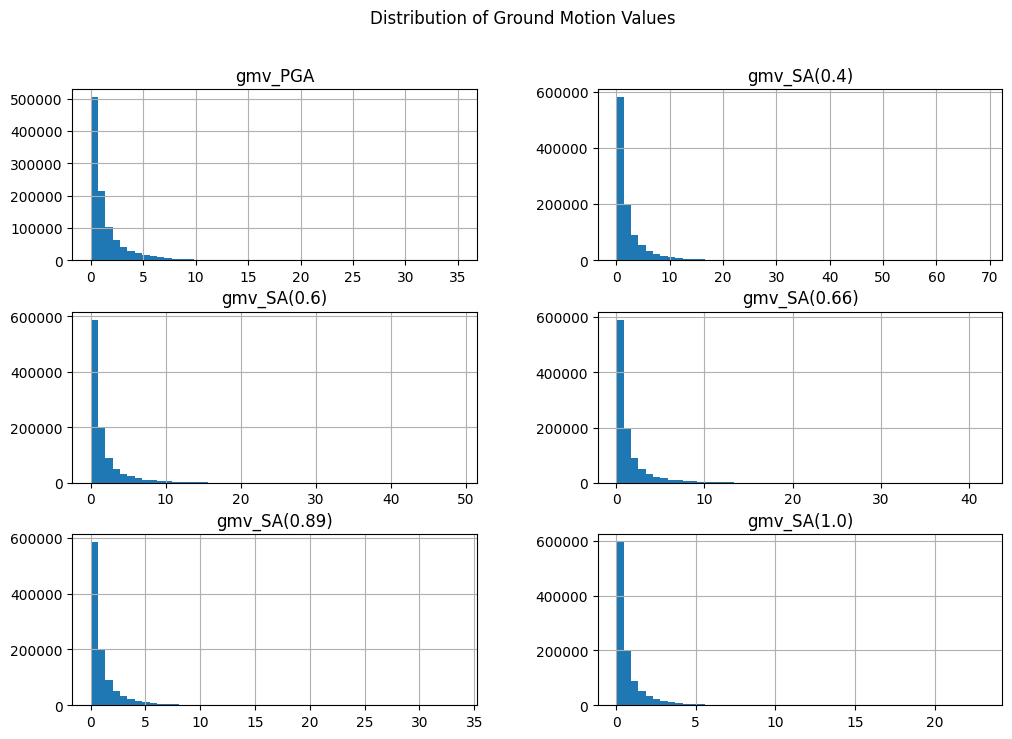

In [11]:
# Histograms
df[gmv_cols].hist(bins=50, figsize=(12, 8))
plt.suptitle('Distribution of Ground Motion Values')
plt.show()

<Figure size 1000x800 with 0 Axes>

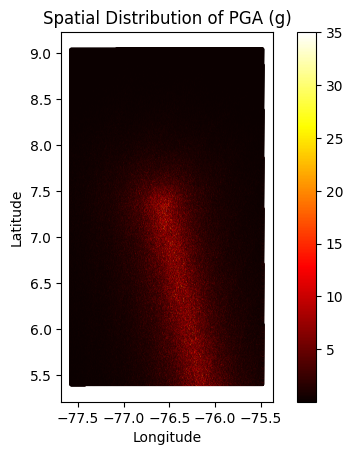

In [12]:
# Spatial distribution (PGA)
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.lon, df.lat), crs="EPSG:4326")

plt.figure(figsize=(10, 8))
gdf.plot(column='gmv_PGA', cmap='hot', markersize=1, legend=True)
plt.title('Spatial Distribution of PGA (g)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

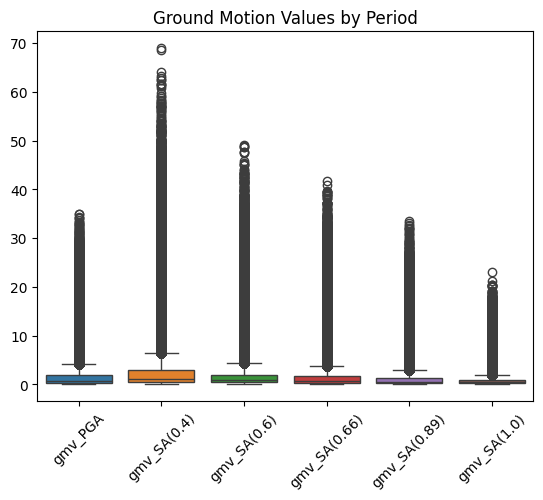

In [13]:
# Boxplot by period
sns.boxplot(data=df[gmv_cols])
plt.title('Ground Motion Values by Period')
plt.xticks(rotation=45)
plt.show()

# Feature Selection

In [14]:
# All GMV columns are important. We can use correlation or domain knowledge.
selected_features = gmv_cols + ['lon', 'lat']
print("Selected Features:", selected_features)

Selected Features: ['gmv_PGA', 'gmv_SA(0.4)', 'gmv_SA(0.6)', 'gmv_SA(0.66)', 'gmv_SA(0.89)', 'gmv_SA(1.0)', 'lon', 'lat']


# Model Development (Simple Example: Clustering High-Risk Zones)

In [15]:
X = df[['lon', 'lat', 'log_gmv_PGA', 'log_gmv_SA(0.4)']].copy()

#X = df[['lon', 'lat', 'gmv_PGA', 'gmv_SA(0.4)']].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['risk_cluster'] = kmeans.fit_predict(X_scaled)

print("\nCluster Distribution:")
print(df['risk_cluster'].value_counts())


Cluster Distribution:
risk_cluster
1    231364
4    222918
2    214189
0    198061
3    182043
Name: count, dtype: int64


# Model Evaluation

In [16]:
# Approximates score significantly faster for large datasets
sil_score = silhouette_score(X_scaled, df['risk_cluster'], sample_size=10000, random_state=42)
print(f'Silhouette Score: {sil_score:.4f}')

Silhouette Score: 0.3262


In [17]:
# Simple validation: Mean PGA per cluster
print("\nMean PGA by Cluster:")
print(df.groupby('risk_cluster')['log_gmv_PGA'].mean().sort_values(ascending=False))


Mean PGA by Cluster:
risk_cluster
4    1.583466
3    0.784913
1    0.584200
2    0.372233
0    0.314204
Name: log_gmv_PGA, dtype: float64


# Result Interpretation

In [18]:
print("\n=== Key Insights ===")
print("Highest Risk Areas (Top 5 by PGA):")
print(df.nlargest(5, 'log_gmv_PGA')[['lon', 'lat', 'log_gmv_PGA', 'gmv_SA(0.4)']])

print("\nAverage GMVs:")
print(df[gmv_cols].mean())


=== Key Insights ===
Highest Risk Areas (Top 5 by PGA):
             lon      lat  log_gmv_PGA  gmv_SA(0.4)
516521 -76.54242  7.36979     3.584391     18.32380
531321 -76.51270  7.28345     3.581489      9.73966
561878 -76.45124  6.83289     3.562434      9.34647
569875 -76.43514  6.74925     3.560108      9.33534
534153 -76.50700  7.39137     3.559704      5.78899

Average GMVs:
gmv_PGA         1.559921
gmv_SA(0.4)     2.505952
gmv_SA(0.6)     1.779634
gmv_SA(0.66)    1.522504
gmv_SA(0.89)    1.211100
gmv_SA(1.0)     0.791518
dtype: float64


# Data Visualization

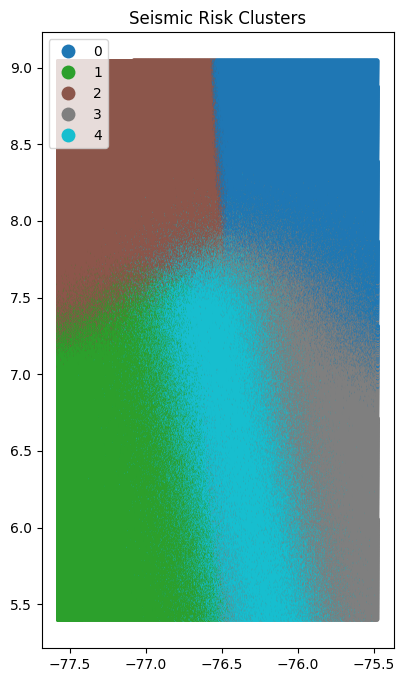

In [23]:
fig, ax = plt.subplots(figsize=(10, 8))
gdf['risk_cluster'] = df['risk_cluster']
gdf.plot(column='risk_cluster', categorical=True, legend=True, cmap='tab10', ax=ax, markersize=2)
plt.title('Seismic Risk Clusters')
plt.show()

In [29]:
df.to_csv('processed_urbancomputing_results.csv', index=False)
print("Processed file saved as 'processed_urbancomputing_results.csv'")

Processed file saved as 'processed_urbancomputing_results.csv'


# Decision Making

In [28]:
high_risk = df[df['log_gmv_PGA'] > 0.8]  # Example threshold (adjust based on building codes)
print(f"High-risk sites (PGA > 0.8g): {len(high_risk)} ({len(high_risk)/len(df)*100:.2f}%)")

High-risk sites (PGA > 0.8g): 373562 (35.63%)
